# Study 295 -- Stablecoin-Supply
## For the curious: does stablecoin supply growth fuel the next leg of Bitcoin?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

Stablecoins -- USDT, USDC, DAI -- are dollars parked on-chain.  The popular
**"dry powder"** thesis says this is cash waiting on the sidelines: when the
*total stablecoin supply grows*, new money has entered crypto and is about to be
deployed into Bitcoin -- so supply growth should **lead** the next leg up.

It is a seductive story.  We test it honestly: does last month's supply growth
*predict* next month's BTC return, or does supply just grow *at the same time* as
prices rise (in which case it forecasts nothing you can trade)?


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stablecoin_supply import data, strategy as st

CACHE_PATH = data.BTC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    btc = data.fetch_btc_monthly(fetch=False, cache_path=CACHE_PATH)
    panel = data.build_real_panel(btc)
    rets = st.timed_returns(panel, window=1, threshold=0.0, one_way_bps=0.0)
    excess = (rets["timed"] - rets["btc"]).dropna()
    print(f"Real panel loaded: {len(panel)} months  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Long {int(rets['weight'].sum())} / flat {int((rets['weight']==0).sum())} months")
else:
    btc = panel = rets = excess = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 101 months  2018-01-31 -> 2026-05-31
Long 77 / flat 24 months


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 101, 'months_long': 77, 'months_flat': 24, 'btc_ann': 41.2, 'btc_sr': 0.61, 'btc_t': 1.51, 'btc_dd': -73.0, 'timed_ann': 49.5, 'timed_sr': 0.85, 'timed_t': 2.09, 'timed_dd': -50.0, 'exc_ann': 8.3, 'exc_t': 0.72, 'exc_hit': 0.129, 'exc_ci_lo': -0.423, 'exc_ci_hi': 0.899, 'exc_frac_neg': 0.213, 'lag1_beta': 0.0417, 'lag1_t': 1.59, 'lag1_r2': 0.047, 'lag1_corr': 0.217, 'lag1_n': 99, 'lag0_beta': 0.0532, 'lag0_t': 2.15, 'lag0_r2': 0.077, 'lag0_corr': 0.277, 'lag0_n': 100, 'sub1_label': '2018-2020', 'sub1_beta': 0.0984, 'sub1_t': 3.05, 'sub1_n': 34, 'sub2_label': '2021-2022', 'sub2_beta': 0.0308, 'sub2_t': 0.75, 'sub2_n': 22, 'sub3_label': '2023-2026', 'sub3_beta': 0.0002, 'sub3_t': 0.01, 'sub3_n': 39, 'turnover_pct': 8.9, 'net10_ann': 49.4, 'net10_t': 2.09, 'net25_ann': 49.3, 'net25_t': 2.08, 'net50_ann': 49.0, 'net50_t': 2.07, 'syn_null_t': -0.13, 'syn_live_t': 3.48, 'syn_live_beta': 0.0386, 'btc_fp': '41dff5f08708', 'panel_fp': 'ae8e27f23d83'}


## The two tapes: stablecoin supply and Bitcoin

We join a curated monthly **total stablecoin supply** series ($bn) with the
BTC-USD monthly tape.  The supply series tells the sector's story: a tiny ~$2bn
in 2018, the 2020-21 DeFi/bull mint wave to ~$180bn, the **May-2022 UST/Luna
collapse** and 2022-23 contraction, then the 2024-26 re-expansion past $250bn.


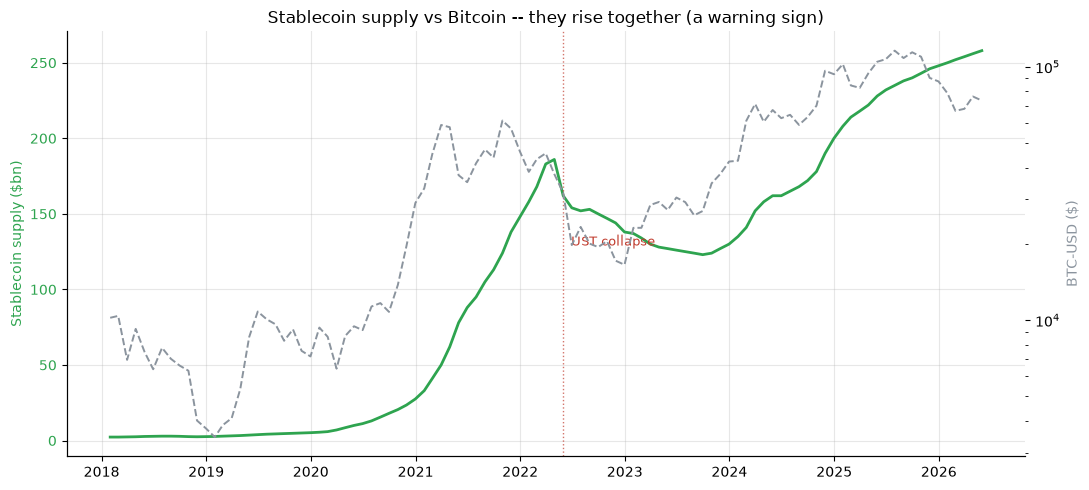

Supply and BTC clearly co-move -- but co-movement is NOT a tradable forecast.


In [3]:
fig, ax1 = plt.subplots(figsize=(11, 5))
supply = data.supply_series()
ax1.plot(supply.index, supply.values, color=GREEN, lw=2, label="Stablecoin supply ($bn)")
ax1.set_ylabel("Stablecoin supply ($bn)", color=GREEN)
ax1.tick_params(axis="y", labelcolor=GREEN)

if HAVE_REAL:
    btc_px = btc.reindex(supply.index).dropna()
    ax2 = ax1.twinx()
    ax2.plot(btc_px.index, btc_px.values, color=GREY, lw=1.4, ls="--", label="BTC-USD")
    ax2.set_ylabel("BTC-USD ($)", color=GREY)
    ax2.set_yscale("log")
    ax2.grid(False)
ax1.set_title("Stablecoin supply vs Bitcoin -- they rise together (a warning sign)")
ax1.axvline(pd.Timestamp("2022-05-31"), color=RED, lw=1, ls=":", alpha=.7)
ax1.text(pd.Timestamp("2022-05-31"), supply.max()*0.5, "  UST collapse", color=RED, fontsize=9)
plt.tight_layout()
plt.savefig("../docs/supply_vs_btc.png", dpi=120, bbox_inches="tight")
plt.show()
print("Supply and BTC clearly co-move -- but co-movement is NOT a tradable forecast.")


## The naive timing rule looks great -- because it just rides Bitcoin

The dry-powder rule: **at each month-end, if supply grew this month, hold BTC
next month; otherwise sit in cash.**  (Strict one-month lag -- no peeking.)


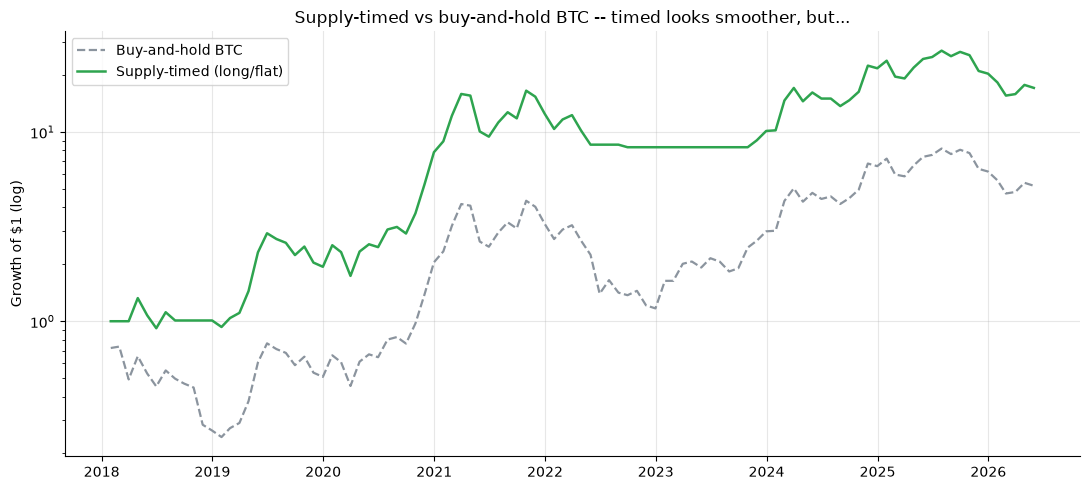

BTC   : +41.2%/yr  SR=0.61  HAC t=+1.51  maxDD=-73%
TIMED : +49.5%/yr  SR=0.85  HAC t=+2.09  maxDD=-50%
EXCESS (timed - BTC): +8.3%/yr  HAC t = +0.72  <- NOT significant


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
if HAVE_REAL:
    cum_btc   = (1 + rets["btc"]).cumprod()
    cum_timed = (1 + rets["timed"]).cumprod()
    ax.plot(cum_btc.index,   cum_btc.values,   color=GREY,  lw=1.6, ls="--", label="Buy-and-hold BTC")
    ax.plot(cum_timed.index, cum_timed.values, color=GREEN, lw=1.8, label="Supply-timed (long/flat)")
    ax.set_yscale("log")
    ax.set_ylabel("Growth of $1 (log)")
    ax.legend(fontsize=10)
    ax.set_title("Supply-timed vs buy-and-hold BTC -- timed looks smoother, but...")
else:
    ax.text(0.5, 0.5, f"Cache absent\nFrozen: timed SR={R['timed_sr']:.2f} vs BTC SR={R['btc_sr']:.2f}\nbut excess t = +{R['exc_t']:.2f} (NOT significant)",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color=AMBER)
    ax.set_title("(frozen numbers)")
plt.tight_layout()
plt.show()
print(f"BTC   : {R['btc_ann']:+.1f}%/yr  SR={R['btc_sr']:.2f}  HAC t={R['btc_t']:+.2f}  maxDD={R['btc_dd']:.0f}%")
print(f"TIMED : {R['timed_ann']:+.1f}%/yr  SR={R['timed_sr']:.2f}  HAC t={R['timed_t']:+.2f}  maxDD={R['timed_dd']:.0f}%")
print(f"EXCESS (timed - BTC): {R['exc_ann']:+.1f}%/yr  HAC t = +{R['exc_t']:.2f}  <- NOT significant")


## The catch: the "edge" is just being long Bitcoin in a bull market

The timed strategy is long BTC in **77 of 101 months**.  During a once-in-a-
generation BTC bull run, *any* mostly-long rule looks good.  The honest question
is whether it beats simply **buying and holding** -- and the excess return is
**+8.3%/yr with HAC *t* = +0.72**.  That is statistically indistinguishable from
zero.  The bootstrap 95% CI on the excess Sharpe is **[-0.42, +0.90]**, with 21%
of resamples negative -- it straddles zero.


## Why supply growth forecasts nothing: reflexivity

Here is the heart of it.  We regress BTC's return on supply growth two ways:

- **Contemporaneous** (this month's supply growth vs this month's BTC return):
  HAC *t* = **+2.15** -- significant.  Supply and price move *together*.
- **Lagged** (last month's supply growth vs this month's BTC return -- the only
  thing you can actually trade): HAC *t* = **+1.59** -- below the t >= 2 bar.

When the *contemporaneous* link is stronger than the *lagged* one, that is the
textbook signature of a **coincident, reflexive series**: stablecoins mint when
money is already flooding in and prices are already rising.  Supply growth is a
mirror of today's enthusiasm, not a window into tomorrow's.


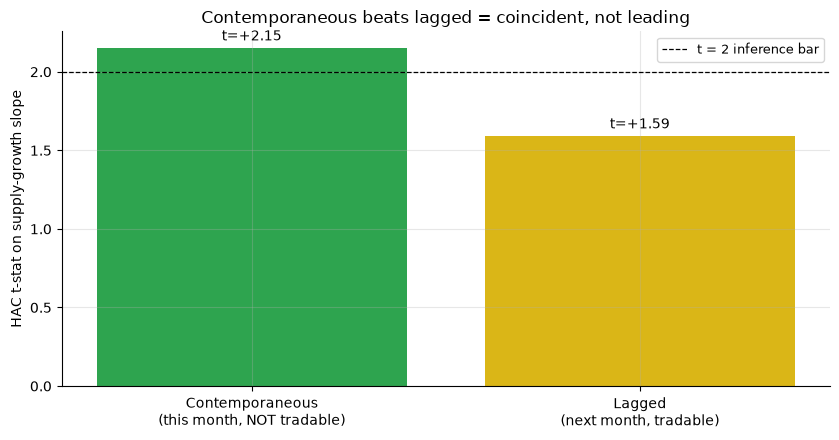

The tradable (lagged) signal clears no inference bar; the significant link is non-tradable.


In [5]:
labels = ["Contemporaneous\n(this month, NOT tradable)", "Lagged\n(next month, tradable)"]
tvals  = [R["lag0_t"], R["lag1_t"]]
colors = [GREEN if t >= 2 else AMBER for t in tvals]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(labels, tvals, color=colors)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t = 2 inference bar")
ax.set_ylabel("HAC t-stat on supply-growth slope")
ax.set_title("Contemporaneous beats lagged = coincident, not leading")
ax.legend(fontsize=9)
for i, t in enumerate(tvals):
    ax.text(i, t + 0.05, f"t={t:+.2f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../docs/reflexivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("The tradable (lagged) signal clears no inference bar; the significant link is non-tradable.")


## And what little there was has decayed to nothing

Splitting the lagged regression by era shows the apparent edge was a
**2018-2020 artefact** that has since vanished -- as the stablecoin sector
matured and the dry-powder thesis became common knowledge.


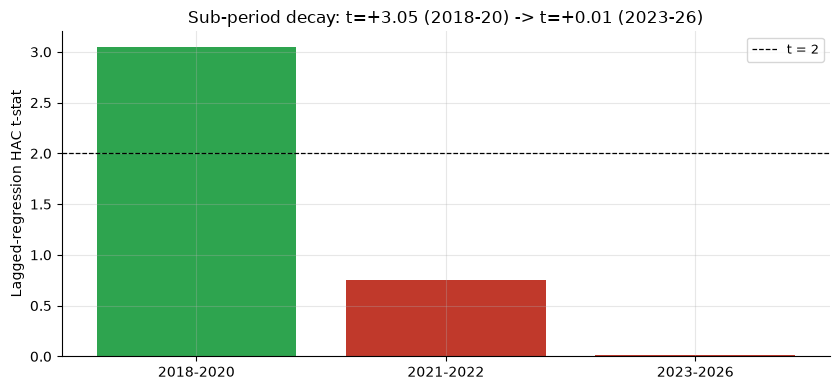

  2018-2020: lagged HAC t = +3.05
  2021-2022: lagged HAC t = +0.75
  2023-2026: lagged HAC t = +0.01


In [6]:
subs = [(R["sub1_label"], R["sub1_t"]), (R["sub2_label"], R["sub2_t"]), (R["sub3_label"], R["sub3_t"])]
fig, ax = plt.subplots(figsize=(8.5, 4))
colors_s = [GREEN if t >= 2 else AMBER if t >= 1 else RED for _, t in subs]
ax.bar([s[0] for s in subs], [s[1] for s in subs], color=colors_s)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t = 2")
ax.set_ylabel("Lagged-regression HAC t-stat")
ax.set_title("Sub-period decay: t=+3.05 (2018-20) -> t=+0.01 (2023-26)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
for lbl, t in subs:
    print(f"  {lbl}: lagged HAC t = {t:+.2f}")


## The bottom line for the curious

The dry-powder story is **half true and entirely untradable**:

- Stablecoin supply genuinely **co-moves** with Bitcoin (contemporaneous t = +2.15).
- But the only thing you can trade -- *last* month's supply growth predicting
  *next* month's return -- clears no bar (t = +1.59), adds no significant return
  over just holding BTC (excess t = +0.72), and has **decayed to zero** since 2020.
- The pretty timed equity curve is BTC's bull-market beta in disguise.

This is a **Weak / Mirage** signal: a reflexive, coincident series dressed up as
a leading indicator.


*Desk verdict: **Weak / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*